In [ ]:
# Adding necessary libraries to Google Colab environment

# Installing the 'contextily' library for adding basemaps to plots
!pip install contextily -q

# Installing the 'splot' library for spatial data visualization
!pip install splot -q

# Installing additional libraries for spatial analysis and visualization
#!pip install rasterio -q  # Library for reading and writing raster data
#!pip install linearmodels==4.27 -q  # Library for linear models and instrumental variables
!pip install mapclassify -q  # Library for choropleth mapping
#!pip install inequality -q  # Library for measuring economic inequality

# Installing the 'mgwr' library for performing geographically weighted regression
!pip install mgwr -q

!pip install stargazer -q

In [ ]:
# Load libraries
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from pylab import rcParams
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 72

import seaborn as sns
sns.set_style("darkgrid")
sns.set_context(context="paper", font_scale=1.5, rc=None)
sns.set(font="serif")

import plotly.express as px
import plotly.graph_objects as go

import geopandas as gpd


import libpysal as ps
from libpysal  import weights
from libpysal.weights import Queen

import esda
from esda.moran import Moran, Moran_Local

import splot
from splot.esda import moran_scatterplot, plot_moran, lisa_cluster, plot_local_autocorrelation
from splot.libpysal import plot_spatial_weights

from giddy.directional import Rose

import statsmodels.api as sm
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer, LineLocation

from spreg import OLS
from spreg import MoranRes
from spreg import ML_Lag
from spreg import ML_Error

from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import shift_colormap, truncate_colormap

import warnings
warnings.filterwarnings('ignore')
import time

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.offsetbox import (AnchoredOffsetbox, HPacker,
                                   VPacker, TextArea, DrawingArea)
from mapclassify import FisherJenks
import numpy as np

from matplotlib.patches import Patch
from mapclassify import FisherJenks
import numpy as np

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from matplotlib.patches import Patch

import urllib.request
from PIL import Image
import io

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/DuHe1123//phd_projects/main/data/Dataset_MGWR.csv", encoding = "utf-8").drop(columns = ['ln_gdp_per_capita', 'ln_gdp_pc_c_sq'])
map = gpd.read_file("https://raw.githubusercontent.com/DuHe1123//phd_projects/main/shapefile/ChinaMainLandADM2_366.geojson", encoding = "utf-8")

In [ ]:
df.columns

Index(['citycode', 'cons_gdp_ratio', 'ln_avg_wage', 'hospital_beds_per10k',
       'gdp_growth', 'pop_density', 'invest_gdp_ratio', 'ln_edu_exp_pc',
       'univ_students_per10k', 'secondary_gdp_ratio', 'tertiary_gdp_ratio',
       'ln_nonagri_gdppc', 'rd_intensity', 'invpat_grant_per10k',
       'unemployment_rate', 'ln_employed_population',
       'medical_insurance_coverage', 'ln_avg_wage_c_sq',
       'ln_nonagri_gdppc_c_sq', 'overwork2019', 'intensityw'],
      dtype='object')

In [ ]:
df.rename(columns={'citycode': 'regionid', 'ln_avg_wage': 'lngdppc', 'ln_avg_wage_c_sq' : 'lngdppc2', 'overwork2019' : 'ratioW'}, inplace=True)

In [ ]:
df.columns

Index(['regionid', 'cons_gdp_ratio', 'lngdppc', 'hospital_beds_per10k',
       'gdp_growth', 'pop_density', 'invest_gdp_ratio', 'ln_edu_exp_pc',
       'univ_students_per10k', 'secondary_gdp_ratio', 'tertiary_gdp_ratio',
       'ln_nonagri_gdppc', 'rd_intensity', 'invpat_grant_per10k',
       'unemployment_rate', 'ln_employed_population',
       'medical_insurance_coverage', 'lngdppc2', 'ln_nonagri_gdppc_c_sq',
       'ratioW', 'intensityw'],
      dtype='object')

In [ ]:
gdf = df.merge(map, left_on='regionid', right_on='RegionCode', how='left')

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(gdf, geometry='geometry')

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   regionid                    366 non-null    int64   
 1   cons_gdp_ratio              297 non-null    float64 
 2   lngdppc                     296 non-null    float64 
 3   hospital_beds_per10k        297 non-null    float64 
 4   gdp_growth                  297 non-null    float64 
 5   pop_density                 290 non-null    float64 
 6   invest_gdp_ratio            290 non-null    float64 
 7   ln_edu_exp_pc               297 non-null    float64 
 8   univ_students_per10k        292 non-null    float64 
 9   secondary_gdp_ratio         297 non-null    float64 
 10  tertiary_gdp_ratio          297 non-null    float64 
 11  ln_nonagri_gdppc            297 non-null    float64 
 12  rd_intensity                267 non-null    float64 
 13  invpat_grant

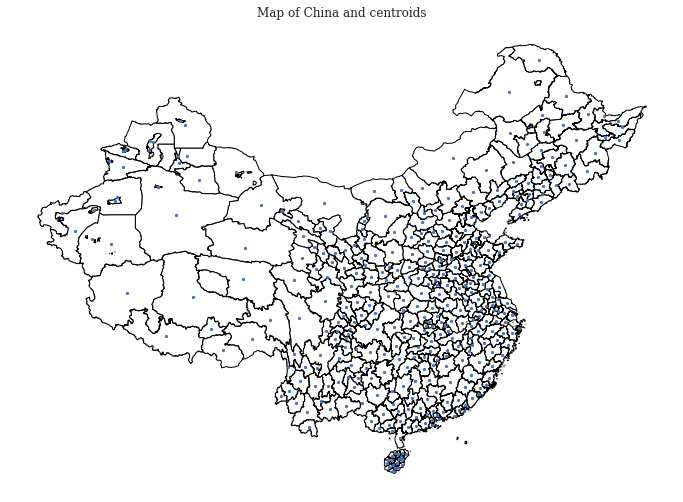

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(color = 'white', edgecolor = 'black', ax = ax)
gdf.centroid.plot(ax=ax, markersize=5)
ax.set_title('Map of China and centroids', fontsize=12)
ax.axis("off")
#plt.savefig('myMap.png',dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
gdf.head()

,regionid,cons_gdp_ratio,lngdppc,hospital_beds_per10k,gdp_growth,pop_density,invest_gdp_ratio,ln_edu_exp_pc,univ_students_per10k,secondary_gdp_ratio,tertiary_gdp_ratio,ln_nonagri_gdppc,rd_intensity,invpat_grant_per10k,unemployment_rate,ln_employed_population,medical_insurance_coverage,lngdppc2,ln_nonagri_gdppc_c_sq,ratioW,intensityw,RegionCode,geometry
0,110000,0.426647,11.680232,81.898605,7.228333,811.33331,0.340645,8.749804,438.82709,0.20045,0.793700,11.632454,0.056386,34.028183,0.006278,7.256831,1.130200,0.465317,1.009284,16.982765,1.780459,110000,"MULTIPOLYGON (((116.62585 41.05887, 116.62638 ..."
1,120000,0.308074,11.374264,57.406654,7.841667,852.33331,0.735917,8.434451,491.81787,0.45055,0.537917,11.605997,0.025454,5.382672,0.023240,6.208052,0.596462,0.144721,0.941673,14.320941,1.685097,120000,"MULTIPOLYGON (((117.43409 40.25176, 117.43425 ..."
2,130100,0.482077,10.957914,47.109268,7.540000,734.33331,0.952277,7.283399,417.78320,0.44674,0.466080,10.763705,0.020761,1.451373,0.005240,5.236296,0.166635,0.038801,0.020634,13.586745,0.538205,130100,"MULTIPOLYGON (((113.81186 38.75786, 113.82276 ..."
3,130200,0.352739,10.979837,48.863686,5.846000,552.33331,0.694403,7.371975,156.23145,0.56308,0.349220,11.223789,0.014232,0.900754,0.007592,4.915935,0.224347,0.023714,0.345131,14.390833,0.777616,130200,"MULTIPOLYGON (((118.27154 38.982, 118.27068 38..."
4,130300,0.495267,11.006867,50.070564,5.336000,377.33334,0.666548,7.295628,528.09937,0.35838,0.500840,10.620678,0.010977,1.906074,0.008626,3.981578,0.230324,0.024321,0.059881,12.472531,0.605791,130300,"MULTIPOLYGON (((119.43533 39.78556, 119.43536 ..."


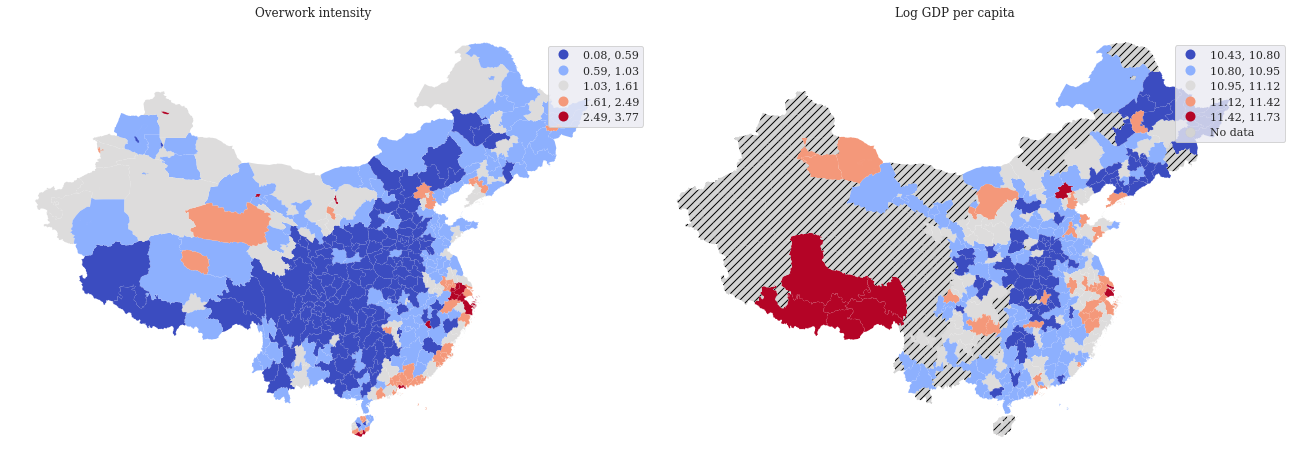

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))  # 1 row, 2 columns

# First map: Overwork ratio
gdf.plot(
    column='intensityw',
    cmap='coolwarm',
    linewidth=0.01,
    scheme='FisherJenks',
    k=5,
    legend=True,
    legend_kwds={'bbox_to_anchor': (1.05, 0.96)},
    ax=axes[0]
)
axes[0].set_title('Overwork intensity', fontsize=12)
axes[0].axis("off")

# Second map: ln(GDP per capita), show all regions including missing
gdf.plot(
    column='lngdppc',
    cmap='coolwarm',
    linewidth=0.01,
    scheme='FisherJenks',
    k=5,
    legend=True,
    legend_kwds={'bbox_to_anchor': (1.05, 0.96)},
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "hatch": "///",
        "label": "No data"
    },
    ax=axes[1]
)
axes[1].set_title('Log GDP per capita', fontsize=12)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
gdf_nona = gdf.dropna(subset=['regionid', 'cons_gdp_ratio', 'hospital_beds_per10k', 'lngdppc',
       'secondary_gdp_ratio', 'tertiary_gdp_ratio', 'rd_intensity',
       'invpat_grant_per10k', 'unemployment_rate', 'ln_employed_population',
       'medical_insurance_coverage', 'lngdppc2', 'ratioW', 'gdp_growth', 'pop_density', 'invest_gdp_ratio',
       'ln_edu_exp_pc', 'univ_students_per10k', 'intensityw'])
gdf_nona = gdf_nona[(gdf_nona['regionid'] != 650200) & (gdf_nona['regionid'] != 650100)].copy()
gdf_nona = gdf_nona.reset_index(drop=True)
gdf_nona.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   regionid                    252 non-null    int64   
 1   cons_gdp_ratio              252 non-null    float64 
 2   lngdppc                     252 non-null    float64 
 3   hospital_beds_per10k        252 non-null    float64 
 4   gdp_growth                  252 non-null    float64 
 5   pop_density                 252 non-null    float64 
 6   invest_gdp_ratio            252 non-null    float64 
 7   ln_edu_exp_pc               252 non-null    float64 
 8   univ_students_per10k        252 non-null    float64 
 9   secondary_gdp_ratio         252 non-null    float64 
 10  tertiary_gdp_ratio          252 non-null    float64 
 11  ln_nonagri_gdppc            252 non-null    float64 
 12  rd_intensity                252 non-null    float64 
 13  invpat_grant

In [ ]:
y = gdf_nona['intensityw'].values.reshape((-1,1)) # reshape is needed to have column array
y.shape

(252, 1)

In [ ]:
X = gdf_nona[['lngdppc', 'lngdppc2', 'cons_gdp_ratio', 'hospital_beds_per10k',
       'secondary_gdp_ratio', 'tertiary_gdp_ratio', 'rd_intensity',
       'invpat_grant_per10k', 'unemployment_rate', 'ln_employed_population',
       'medical_insurance_coverage', 'gdp_growth', 'pop_density', 'invest_gdp_ratio',
       'ln_edu_exp_pc', 'univ_students_per10k']].values
X.shape

(252, 16)

In [ ]:
# prompt: give gdf two variables, X, and Y, which is the coordinates of the centroids of the regions

gdf_nona['X'] = gdf_nona.centroid.x.values.reshape((-1,1))
gdf_nona['Y'] = gdf_nona.centroid.y.values.reshape((-1,1))

In [ ]:
u = gdf_nona['X']
v = gdf_nona['Y']
coords = list(zip(u,v))

In [ ]:
# Ordinary Least Squares Regression
# Define the dependent and independent variables
y_ols = gdf_nona['intensityw']
X_ols = gdf_nona[['cons_gdp_ratio', 'hospital_beds_per10k', 'lngdppc',
       'secondary_gdp_ratio', 'tertiary_gdp_ratio', 'rd_intensity',
       'invpat_grant_per10k', 'unemployment_rate', 'ln_employed_population',
       'medical_insurance_coverage', 'lngdppc2', 'gdp_growth', 'pop_density', 'invest_gdp_ratio',
       'ln_edu_exp_pc', 'univ_students_per10k']]
X_ols = sm.add_constant(X_ols) # Add a constant term for the intercept

# Combine y and X for easier handling of missing data
ols_data = pd.concat([y_ols, X_ols], axis=1)

# Drop rows with any NaN values in the OLS relevant columns
ols_data = ols_data.dropna()

# Separate y and X again from the cleaned data
y_ols_cleaned = ols_data['intensityw']
X_ols_cleaned = ols_data[['const', 'lngdppc', 'lngdppc2', 'cons_gdp_ratio', 'hospital_beds_per10k',
       'secondary_gdp_ratio', 'tertiary_gdp_ratio', 'rd_intensity',
       'invpat_grant_per10k', 'unemployment_rate', 'ln_employed_population',
       'medical_insurance_coverage', 'gdp_growth', 'pop_density', 'invest_gdp_ratio',
       'ln_edu_exp_pc', 'univ_students_per10k']]


# Fit the OLS model using the cleaned data
ols_model = sm.OLS(y_ols_cleaned, X_ols_cleaned)
ols_results = ols_model.fit()

# Print the regression summary
print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:             intensityw   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     15.04
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           7.30e-28
Time:                        08:02:53   Log-Likelihood:                -171.07
No. Observations:                 252   AIC:                             376.1
Df Residuals:                     235   BIC:                             436.1
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [ ]:
Zy = (y - y.mean(axis=0)) / y.std(axis=0)
ZX = (X - X.mean(axis=0)) / X.std(axis=0)

# GWR

In [ ]:
%%time
gwr_selector = Sel_BW(coords, y, X)
gwr_bw = gwr_selector.search()

CPU times: user 388 ms, sys: 28.5 ms, total: 416 ms
Wall time: 8.92 s


In [ ]:
print('GWR bandwidth =', gwr_bw)

GWR bandwidth = 126.0


In [ ]:
gwr_results = GWR(coords, Zy, ZX, gwr_bw).fit()
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                 252
Number of covariates:                                                    17

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            124.506
Log-likelihood:                                                    -268.733
AIC:                                                                571.465
AICc:                                                               576.401
BIC:                                                              -1174.910
R2:                                                                   0.506
Adj. R2:                                                              0.472

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

# MGWR

In [ ]:
mgwr_selector = Sel_BW(coords, Zy, ZX, multi=True)
mgwr_bw = mgwr_selector.search()
mgwr_bw

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

array([172., 102.,  95., 214.,  52.,  92., 236., 251., 152., 251., 251.,
       241.,  65., 198., 251.,  56., 250.])

In [ ]:
mgwr_results = MGWR(coords, Zy, ZX, mgwr_selector).fit()
mgwr_results.summary()

Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Model type                                                         Gaussian
Number of observations:                                                 252
Number of covariates:                                                    17

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            124.506
Log-likelihood:                                                    -268.733
AIC:                                                                571.465
AICc:                                                               576.401
BIC:                                                              -1174.910
R2:                                                                   0.506
Adj. R2:                                                              0.472

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [ ]:
mgwr_bw_ci = mgwr_results.get_bws_intervals(mgwr_selector)
print(mgwr_bw_ci)

[(172.0, 172.0), (102.0, 122.0), (92.0, 96.0), (172.0, 214.0), (52.0, 61.0), (92.0, 122.0), (172.0, 240.0), (202.0, 251.0), (151.0, 172.0), (202.0, 251.0), (202.0, 251.0), (202.0, 242.0), (61.0, 73.0), (172.0, 202.0), (202.0, 251.0), (54.0, 61.0), (202.0, 250.0)]


In [ ]:
gdf_nona['mgwr_intercept'] = mgwr_results.params[:,0]
gdf_nona['mgwr_lngdppc']        = mgwr_results.params[:,1]
gdf_nona['mgwr_lngdppc2']        = mgwr_results.params[:,2]
gdf_nona['mgwr_cons_gdp_ratio']        = mgwr_results.params[:,3]
gdf_nona['mgwr_hospital_beds_per10k']        = mgwr_results.params[:,4]
gdf_nona['mgwr_secondary_gdp_ratio']        = mgwr_results.params[:,5]
gdf_nona['mgwr_tertiary_gdp_ratio']        = mgwr_results.params[:,6]
gdf_nona['mgwr_rd_intensity']        = mgwr_results.params[:,7]
gdf_nona['mgwr_invpat_grant_per10k']        = mgwr_results.params[:,8]
gdf_nona['mgwr_unemployment_rate']        = mgwr_results.params[:,9]
gdf_nona['mgwr_ln_employed_population']        = mgwr_results.params[:,10]
gdf_nona['mgwr_medical_insurance_coverage']        = mgwr_results.params[:,11]
gdf_nona['mgwr_gdp_growth']        = mgwr_results.params[:,12]
gdf_nona['mgwr_pop_density']        = mgwr_results.params[:,13]
gdf_nona['mgwr_invest_gdp_ratio']        = mgwr_results.params[:,14]
gdf_nona['mgwr_ln_edu_exp_pc']        = mgwr_results.params[:,15]
gdf_nona['mgwr_univ_students_per10k']        = mgwr_results.params[:,16]

In [ ]:
# Filter t-values: standard alpha = 0.05
mgwr_filtered_t = mgwr_results.filter_tvals(alpha = 0.05)

In [ ]:
# Filter t-values: corrected alpha due to multiple testing
mgwr_filtered_tc = mgwr_results.filter_tvals()

In [ ]:
pd.DataFrame(mgwr_filtered_t).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
count,252.000000,252.0,252.000000,252.0,252.000000,252.0,252.0,252.0,252.000000,252.000000,252.0,252.000000,252.000000,252.000000,252.0,252.000000,252.0
mean,-3.902935,0.0,-1.059398,0.0,-1.697971,0.0,0.0,0.0,1.597485,2.762161,0.0,0.183852,0.310663,1.211144,0.0,1.761528,0.0
std,0.767857,0.0,1.725547,0.0,1.730031,0.0,0.0,0.0,1.341830,0.169299,0.0,0.596646,1.866919,1.333812,0.0,1.811202,0.0
min,-5.237706,0.0,-5.444686,0.0,-4.886759,0.0,0.0,0.0,0.000000,2.432713,0.0,0.000000,-3.126907,0.000000,0.0,0.000000,0.0
25%,-4.602703,0.0,-2.335408,0.0,-2.708322,0.0,0.0,0.0,0.000000,2.639191,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
50%,-3.860616,0.0,0.000000,0.0,-2.202834,0.0,0.0,0.0,2.388735,2.741311,0.0,0.000000,0.000000,0.000000,0.0,2.143194,0.0
75%,-3.217541,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,2.752549,2.865496,0.0,0.000000,0.000000,2.637698,0.0,2.777135,0.0
max,-2.692773,0.0,0.000000,0.0,2.344167,0.0,0.0,0.0,3.313115,3.166786,0.0,2.350692,5.283752,3.101135,0.0,5.950917,0.0


In [ ]:
pd.DataFrame(mgwr_filtered_tc).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
count,252.000000,252.0,252.000000,252.0,252.000000,252.0,252.0,252.0,252.000000,252.000000,252.0,252.000000,252.000000,252.000000,252.0,252.000000,252.0
mean,-3.902935,0.0,-0.822851,0.0,-0.826846,0.0,0.0,0.0,1.435261,2.762161,0.0,0.120701,0.268972,1.028095,0.0,1.047911,0.0
std,0.767857,0.0,1.696177,0.0,1.711551,0.0,0.0,0.0,1.394176,0.169299,0.0,0.499171,1.687718,1.343402,0.0,1.893285,0.0
min,-5.237706,0.0,-5.444686,0.0,-4.886759,0.0,0.0,0.0,0.000000,2.432713,0.0,0.000000,-3.126907,0.000000,0.0,0.000000,0.0
25%,-4.602703,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,2.639191,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
50%,-3.860616,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,2.388735,2.741311,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
75%,-3.217541,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,2.752549,2.865496,0.0,0.000000,0.000000,2.637698,0.0,2.777135,0.0
max,-2.692773,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,3.313115,3.166786,0.0,2.350692,5.283752,3.101135,0.0,5.950917,0.0


In [ ]:
gdf = gdf.merge(
    gdf_nona[[
        'regionid',
        'mgwr_intercept',
        'mgwr_lngdppc',
        'mgwr_lngdppc2',
        'mgwr_cons_gdp_ratio',
        'mgwr_hospital_beds_per10k',
        'mgwr_secondary_gdp_ratio',
        'mgwr_tertiary_gdp_ratio',
        'mgwr_rd_intensity',
        'mgwr_invpat_grant_per10k',
        'mgwr_unemployment_rate',
        'mgwr_ln_employed_population',
        'mgwr_medical_insurance_coverage',
        'mgwr_gdp_growth',
        'mgwr_pop_density',
        'mgwr_invest_gdp_ratio',
        'mgwr_ln_edu_exp_pc',
        'mgwr_univ_students_per10k'
    ]],
    on='regionid',
    how='left'
)

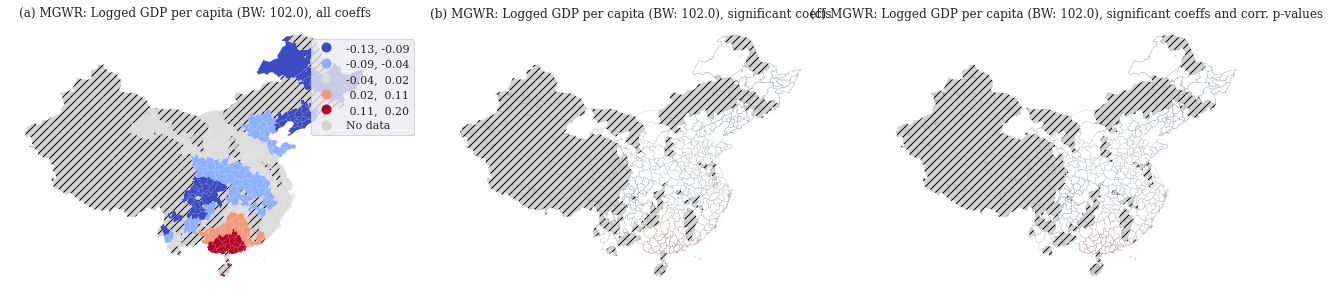

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,6))

# Plot 1: All coefficients on original gdf for context
gdf.plot(column='mgwr_lngdppc', cmap = 'coolwarm', linewidth=0.01, scheme = 'FisherJenks', k=5, legend=True, legend_kwds={'bbox_to_anchor':(1.10, 0.96)},
        missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "hatch": "///",
        "label": "No data"
        },  ax=axes[0])

# Plot 2: Significant coefficients based on standard alpha
# Plot the base map with all regions
gdf.plot(column='mgwr_lngdppc', cmap = 'coolwarm', linewidth=0.05, scheme = 'FisherJenks', k=5, legend=False, legend_kwds={'bbox_to_anchor':(1.10, 0.96)},
         missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "hatch": "///",
        "label": "No data"
        }, ax=axes[1])
# Plot only the regions where the coefficient is not significant (t-value == 0)
# We use gdf_nona for filtering as gwr_filtered_t corresponds to gdf_nona
if not gdf_nona[mgwr_filtered_t[:,1] == 0].empty:
    gdf_nona[mgwr_filtered_t[:,1] == 0].plot(color='white', linewidth=0.05, edgecolor='black', ax=axes[1])


# Plot 3: Significant coefficients based on corrected alpha
# Plot the base map with all regions
gdf.plot(column='mgwr_lngdppc', cmap = 'coolwarm', linewidth=0.05, scheme = 'FisherJenks', k=5, legend=False, legend_kwds={'bbox_to_anchor':(1.10, 0.96)},
         missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "hatch": "///",
        "label": "No data"
        },  ax=axes[2])
# Plot only the regions where the coefficient is not significant (t-value == 0)
# We use gdf_nona for filtering as gwr_filtered_tc corresponds to gdf_nona
if not gdf_nona[mgwr_filtered_tc[:,1] == 0].empty:
    gdf_nona[mgwr_filtered_tc[:,1] == 0].plot(color='white', linewidth=0.05, edgecolor='black', ax=axes[2])

plt.tight_layout()

axes[0].axis("off")
axes[1].axis("off")
axes[2].axis("off")

axes[0].set_title('(a) MGWR: Logged GDP per capita (BW: ' + str(mgwr_bw[1]) +'), all coeffs', fontsize=12)
axes[1].set_title('(b) MGWR: Logged GDP per capita (BW: ' + str(mgwr_bw[1]) +'), significant coeffs',     fontsize=12)
axes[2].set_title('(c) MGWR: Logged GDP per capita (BW: ' + str(mgwr_bw[1]) +'), significant coeffs and corr. p-values',     fontsize=12)
plt.show()

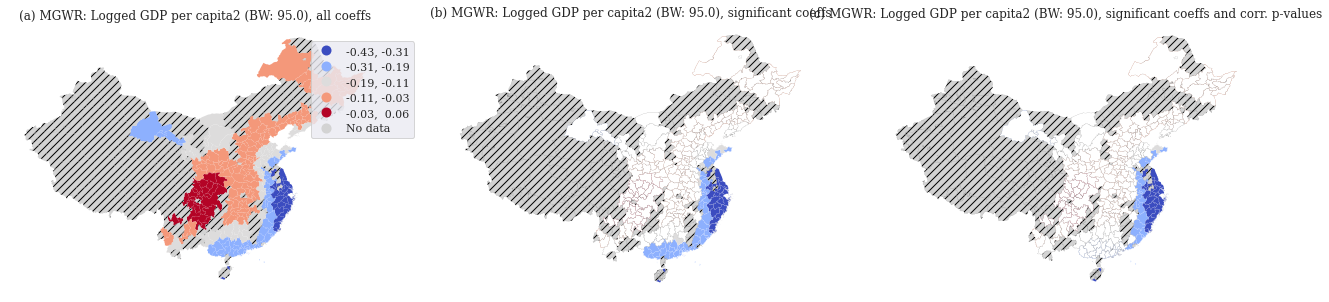

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,6))

# Plot 1: All coefficients on original gdf for context
gdf.plot(column='mgwr_lngdppc2', cmap = 'coolwarm', linewidth=0.01, scheme = 'FisherJenks', k=5, legend=True, legend_kwds={'bbox_to_anchor':(1.10, 0.96)},
        missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "hatch": "///",
        "label": "No data"
        },  ax=axes[0])

# Plot 2: Significant coefficients based on standard alpha
# Plot the base map with all regions
gdf.plot(column='mgwr_lngdppc2', cmap = 'coolwarm', linewidth=0.05, scheme = 'FisherJenks', k=5, legend=False, legend_kwds={'bbox_to_anchor':(1.10, 0.96)},
         missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "hatch": "///",
        "label": "No data"
        }, ax=axes[1])
# Plot only the regions where the coefficient is not significant (t-value == 0)
# We use gdf_nona for filtering as gwr_filtered_t corresponds to gdf_nona
gdf_nona[mgwr_filtered_t[:,2] == 0].plot(color='white', linewidth=0.05, edgecolor='black', ax=axes[1])


# Plot 3: Significant coefficients based on corrected alpha
# Plot the base map with all regions
gdf.plot(column='mgwr_lngdppc2', cmap = 'coolwarm', linewidth=0.05, scheme = 'FisherJenks', k=5, legend=False, legend_kwds={'bbox_to_anchor':(1.10, 0.96)},
         missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "hatch": "///",
        "label": "No data"
        },  ax=axes[2])
# Plot only the regions where the coefficient is not significant (t-value == 0)
# We use gdf_nona for filtering as gwr_filtered_tc corresponds to gdf_nona
gdf_nona[mgwr_filtered_tc[:,2] == 0].plot(color='white', linewidth=0.05, edgecolor='black', ax=axes[2])

plt.tight_layout()

axes[0].axis("off")
axes[1].axis("off")
axes[2].axis("off")

axes[0].set_title('(a) MGWR: Logged GDP per capita2 (BW: ' + str(mgwr_bw[2]) +'), all coeffs', fontsize=12)
axes[1].set_title('(b) MGWR: Logged GDP per capita2 (BW: ' + str(mgwr_bw[2]) +'), significant coeffs',     fontsize=12)
axes[2].set_title('(c) MGWR: Logged GDP per capita2 (BW: ' + str(mgwr_bw[2]) +'), significant coeffs and corr. p-values',     fontsize=12)
plt.show()

In [ ]:
# === Load compass image ===
url = "https://raw.githubusercontent.com/DuHe1123/phd_projects/main/figs/compass.png"
with urllib.request.urlopen(url) as response:
    image_data = response.read()
compass_img = Image.open(io.BytesIO(image_data))

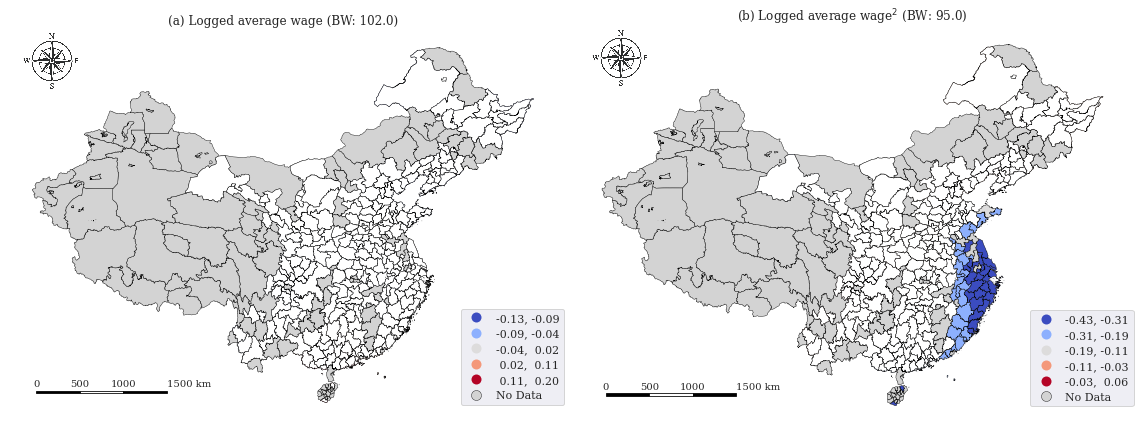

In [ ]:
# === Calculate km to degrees conversion ===
lat_center = gdf.geometry.centroid.y.mean()
km_per_degree = 111.32 * np.cos(np.radians(lat_center))

# === Define scale bar ===
bar_height = 0.2
segment_km = 500
segment_len_deg = segment_km / km_per_degree
x0 = gdf.total_bounds[0] + 0.5  # start of scale bar
y0 = gdf.total_bounds[1] + 1

# === Create subplots ===
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# === Function to plot each map ===
def plot_mgwr_map(ax, gdf, coef_col, sig_mask, title, bw, compass_img):
    # Plot base map
    gdf.plot(
        column=coef_col,
        cmap='coolwarm',
        linewidth=0.4,
        edgecolor='black',
        scheme='FisherJenks',
        k=5,
        legend=True,
        legend_kwds={
            'bbox_to_anchor': (1.02, 0.3),
            'title': None
        },
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "label": "No Data"
        },
        ax=ax
    )

    # Overlay insignificant regions
    gdf_nona[sig_mask == 0].plot(
        color='white',
        linewidth=0.4,
        edgecolor='black',
        ax=ax
    )

    # Add compass
    imagebox = OffsetImage(compass_img, zoom=0.06, alpha=0.9)
    compass_ab = AnnotationBbox(imagebox, (0.08, 0.92), frameon=False,
                                xycoords='axes fraction', zorder=10)
    ax.add_artist(compass_ab)

    # Add scale bar: 3 segments (500 km each)
    for i in range(3):
        color = 'black' if i % 2 == 0 else 'white'
        ax.add_patch(Rectangle((x0 + i * segment_len_deg, y0),
                               segment_len_deg, bar_height,
                               facecolor=color, edgecolor='black',
                               linewidth=0.8, zorder=6))

    # Add tick labels: 0, 500, 1000 aligned under ticks; 1500 km spaced right
    for i, km in enumerate([0, 500, 1000]):
        ax.text(x0 + i * segment_len_deg, y0 + bar_height + 0.2,
                f'{km}', ha='center', va='bottom', fontsize=10, zorder=7)

    # Shift 1500 km label rightward to match interval spacing
    ax.text(x0 + 3 * segment_len_deg + 0.0, y0 + bar_height + 0.2,
            '1500 km', ha='left', va='bottom', fontsize=10, zorder=7)

    # Final title and cleanup
    ax.set_title(title + f' (BW: {bw:.1f})', fontsize=12)
    ax.axis("off")

# === Plot left: ln wage ===
plot_mgwr_map(
    axes[0], gdf, 'mgwr_lngdppc', mgwr_filtered_tc[:, 1],
    '(a) Logged average wage', mgwr_bw[1], compass_img
)

# === Plot right: ln wage^2 ===
plot_mgwr_map(
    axes[1], gdf, 'mgwr_lngdppc2', mgwr_filtered_tc[:, 2],
    '(b) Logged average wage$^2$', mgwr_bw[2], compass_img
)

plt.tight_layout()
plt.savefig("mgwr_ln_wage_combined.png", dpi=300, bbox_inches='tight')
plt.show()


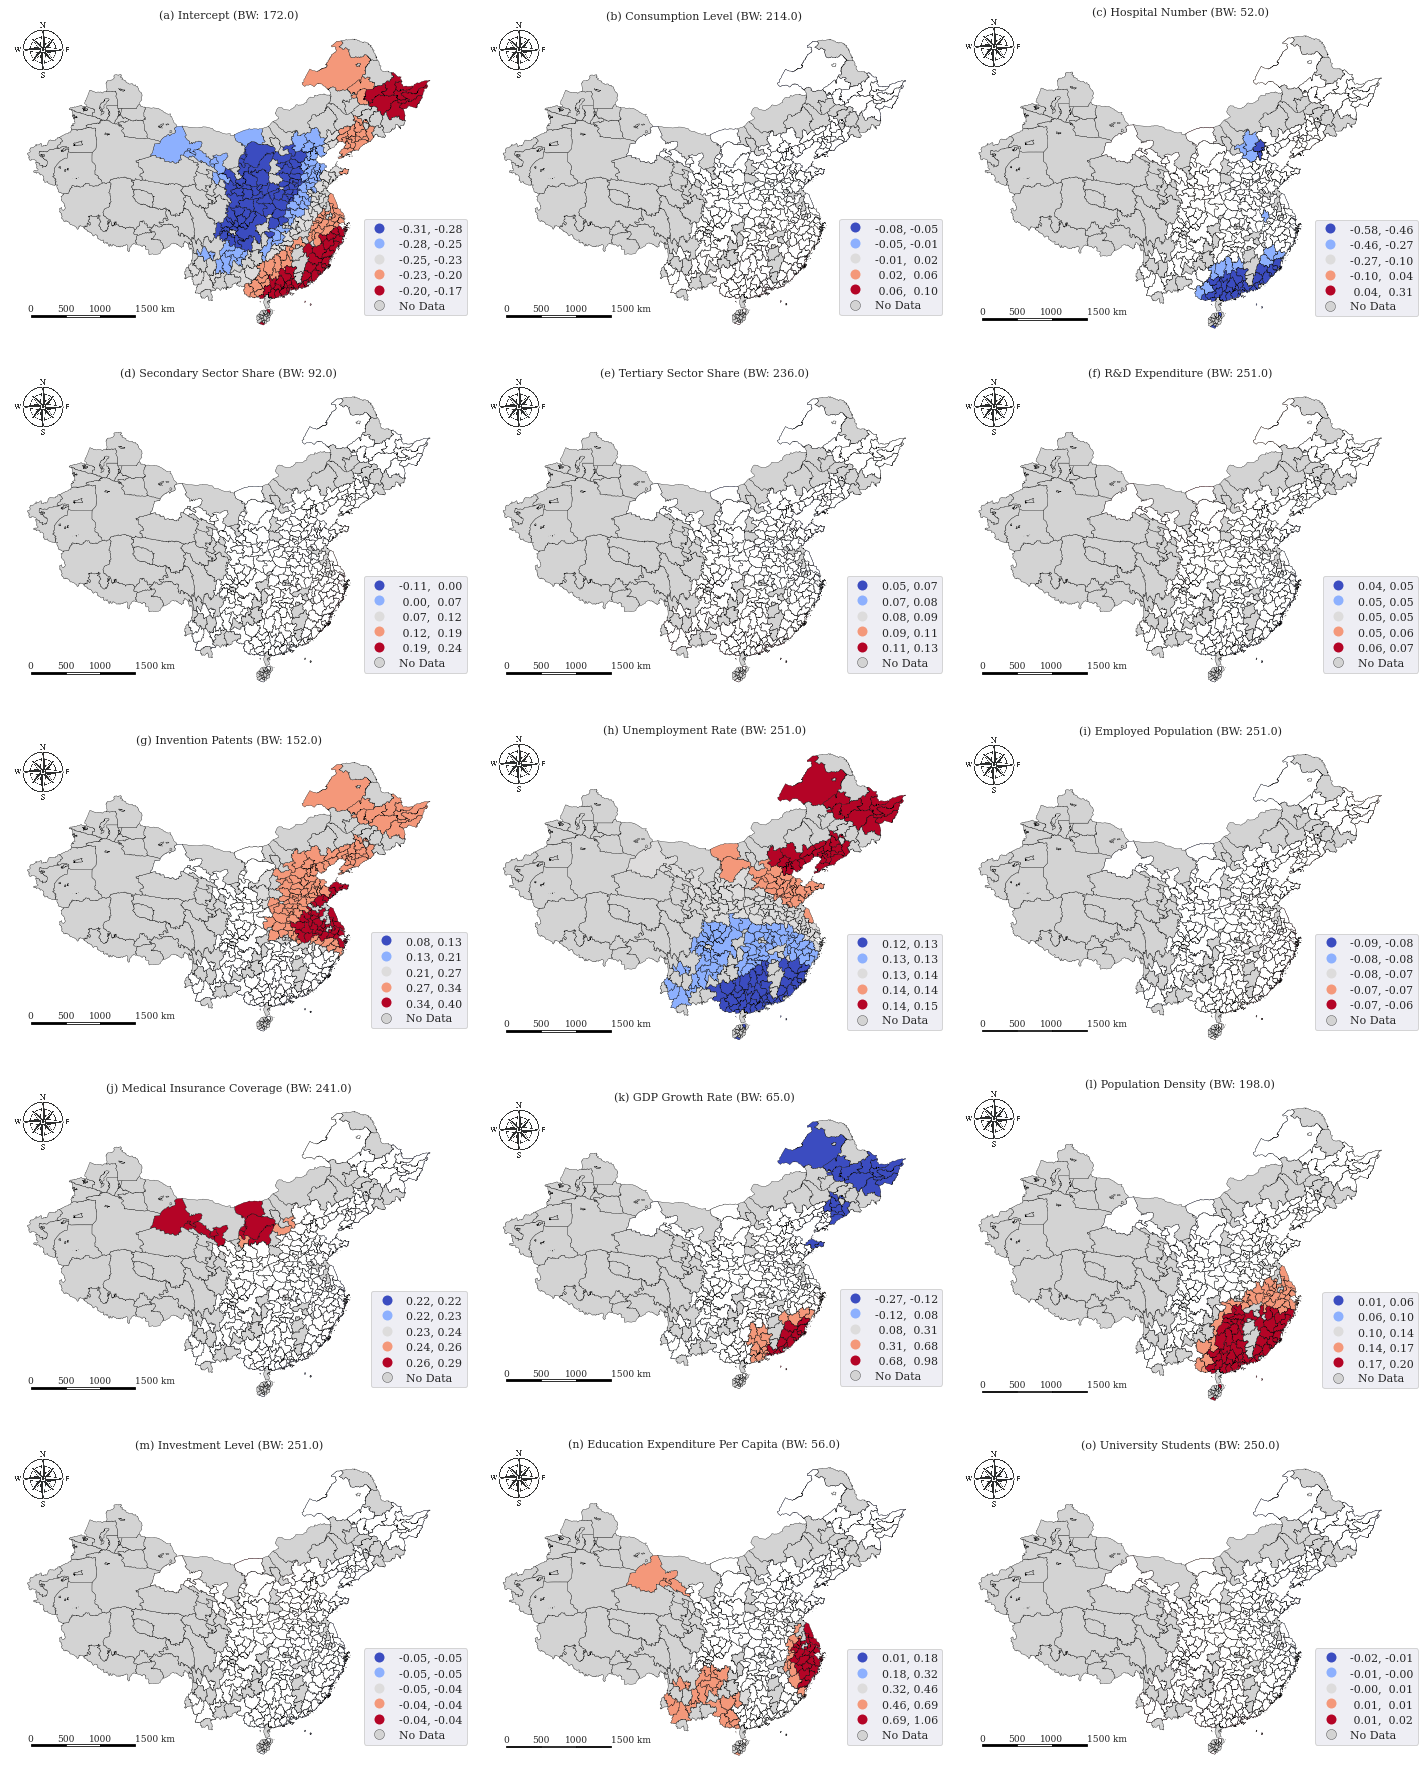

In [ ]:
control_variables = [
    'cons_gdp_ratio',
    'hospital_beds_per10k',
    'secondary_gdp_ratio',
    'tertiary_gdp_ratio',
    'rd_intensity',
    'invpat_grant_per10k',
    'unemployment_rate',
    'ln_employed_population',
    'medical_insurance_coverage',
    'gdp_growth',
    'pop_density',
    'invest_gdp_ratio',
    'ln_edu_exp_pc',
    'univ_students_per10k'
]

titles = [
    "Intercept",
    "Consumption Level",
    "Hospital Number",
    "Secondary Sector Share",
    "Tertiary Sector Share",
    "R&D Expenditure",
    "Invention Patents",
    "Unemployment Rate",
    "Employed Population",
    "Medical Insurance Coverage",
    "GDP Growth Rate",
    "Population Density",
    "Investment Level",
    "Education Expenditure Per Capita",
    "University Students"
]

variable_list_for_X = ['intercept', 'lngdppc', 'lngdppc2'] + control_variables
plot_variables = ['intercept'] + control_variables  # include intercept in the plot
num_vars = len(plot_variables)
ncols = 3
nrows = -(-num_vars // ncols)  # ceiling division

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for i, var_name in enumerate(plot_variables):
    ax = axes[i]
    if var_name == 'intercept':
        var_index = 0
        mgwr_col_name = 'mgwr_intercept'
    else:
        var_index = variable_list_for_X.index(var_name)  # already includes intercept
        mgwr_col_name = f'mgwr_{var_name}'
    bw = mgwr_bw[var_index]

    # Plot base map
    gdf.plot(
        column=mgwr_col_name,
        cmap='coolwarm',
        linewidth=0.3,
        edgecolor='black',
        scheme='FisherJenks',
        k=5,
        legend=True,
        legend_kwds={'bbox_to_anchor': (1.05, 0.4)},
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "label": "No Data"
        },
        ax=ax
    )

    # Overlay insignificant regions (white)
    if not gdf_nona[mgwr_filtered_tc[:, var_index] == 0].empty:
        gdf_nona[mgwr_filtered_tc[:, var_index] == 0].plot(
            color='white', edgecolor='black', linewidth=0.3, ax=ax
        )

    # Add compass
    imagebox = OffsetImage(compass_img, zoom=0.06, alpha=0.9)
    compass_ab = AnnotationBbox(imagebox, (0.08, 0.92), frameon=False,
                                xycoords='axes fraction', zorder=10)
    ax.add_artist(compass_ab)

    # Add scale bar
    for j in range(3):
        color = 'black' if j % 2 == 0 else 'white'
        ax.add_patch(Rectangle((x0 + j * segment_len_deg, y0),
                               segment_len_deg, bar_height,
                               facecolor=color, edgecolor='black',
                               linewidth=0.8, zorder=6))

    for j, km in enumerate([0, 500, 1000]):
        ax.text(x0 + j * segment_len_deg, y0 + bar_height + 0.2,
                f'{km}', ha='center', va='bottom', fontsize=9, zorder=7)

    ax.text(x0 + 3 * segment_len_deg + 0.0, y0 + bar_height + 0.2,
            '1500 km', ha='left', va='bottom', fontsize=9, zorder=7)

    # === Set title manually here ===
    # ax.set_title(f"({chr(97 + i)}) CUSTOM TITLE HERE (BW: {bw:.1f})", fontsize=11)
    # Example:
    ax.set_title(f"({chr(97 + i)}) {titles[i]} (BW: {bw:.1f})", fontsize=11)  # Edit this line per subplot

    ax.axis("off")

plt.tight_layout()
plt.savefig("mgwr_controls.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
%%time
# Monte Carlo test of spatial variability: 10 iterations
mgwr_p_values_stationarity = mgwr_results.spatial_variability(mgwr_selector, 10)

Testing:   0%|          | 0/10 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

...

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

CPU times: user 23min 35s, sys: 1min 21s, total: 24min 56s
Wall time: 49min 56s


In [ ]:
mgwr_p_values_stationarity
# Note:  The first p-value is for the intercept

array([0.6, 0.4, 0. , 0.1, 0.1, 0.1, 0. , 0.9, 0.6, 0.8, 1. , 0.7, 0. ,
       0. , 1. , 0. , 0.7])

In [ ]:
mgwrCN, mgwrVDP = mgwr_results.local_collinearity()

In [ ]:
gdf_nona['mgwr_CN'] = mgwrCN

In [ ]:
gdf = gdf.merge(gdf_nona[['regionid', 'mgwr_CN']], on = 'regionid', how = 'left')

In [ ]:
gdf_nona['mgwr_CN'].describe()

,mgwr_CN
count,252.000000
mean,10.130054
std,2.485137
min,6.291172
25%,8.036094
50%,9.811063
75%,11.577886
max,18.437334


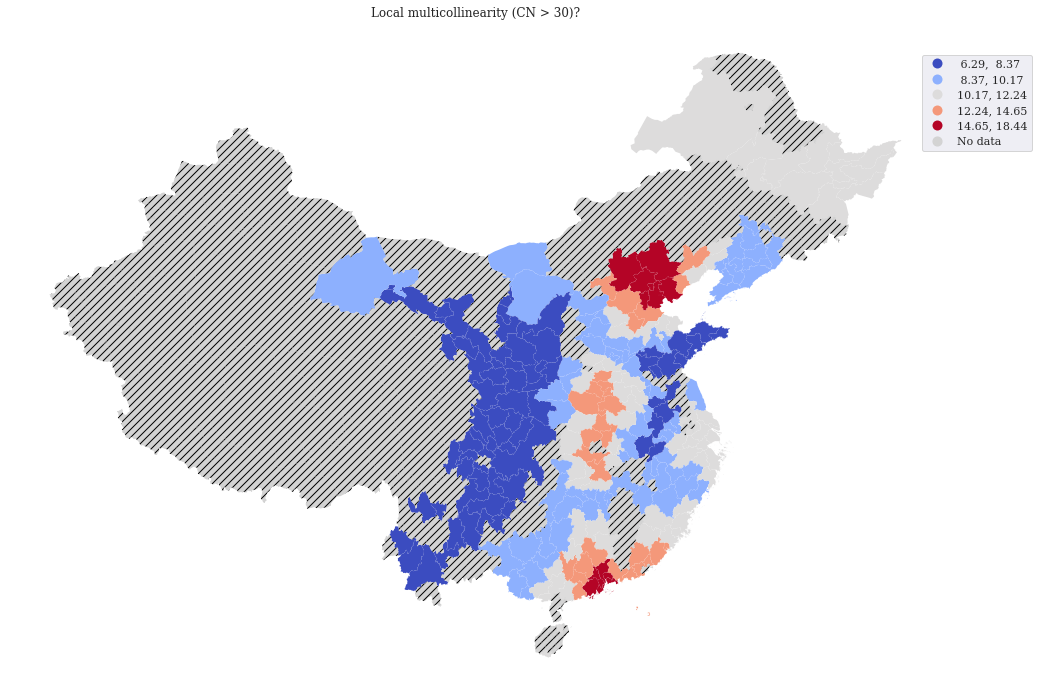

In [ ]:
fig, ax = plt.subplots(figsize=(20, 12))
gdf.plot(column='mgwr_CN', cmap = 'coolwarm', linewidth=0.01, scheme = 'FisherJenks', k=5, legend=True, legend_kwds={'bbox_to_anchor':(1.10, 0.96)}, missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "hatch": "///",
        "label": "No data"
        },  ax=ax)
ax.set_title('Local multicollinearity (CN > 30)?', fontsize=12)
ax.axis("off")
#plt.savefig('myMap.png',dpi=150, bbox_inches='tight')
plt.show()

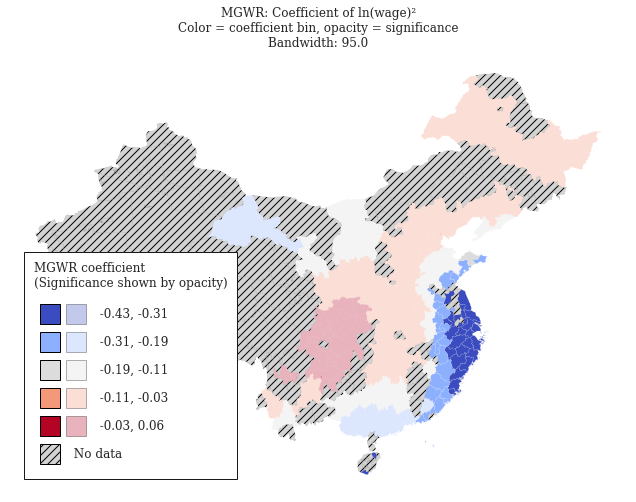

In [ ]:
# ————————————————————————————————————————————
# 1.  Bin edges (same as 3-panel)
# ————————————————————————————————————————————
all_vals = gdf['mgwr_lngdppc2'].dropna()
bins = FisherJenks(all_vals, k=5).bins

# ————————————————————————————————————————————
# 2.  Base map
# ————————————————————————————————————————————
fig, ax = plt.subplots(figsize=(9, 9))

# Significant (opaque)
gdf[gdf['significant'] == 1].plot(
    column='mgwr_lngdppc2',
    cmap='coolwarm',
    scheme='UserDefined',
    classification_kwds={'bins': bins},
    linewidth=0.05,
    ax=ax,
    alpha=1.0
)

# Non-significant (same color, faded)
gdf[gdf['significant'] == 0].plot(
    column='mgwr_lngdppc2',
    cmap='coolwarm',
    scheme='UserDefined',
    classification_kwds={'bins': bins},
    linewidth=0.05,
    ax=ax,
    alpha=0.3
)

# Missing data (hatched)
gdf[gdf['significant'].isna()].plot(
    color='lightgrey',
    edgecolor='black',
    hatch='///',
    linewidth=0.05,
    ax=ax
)

# ————————————————————————————————————————————
# 3.  Side-by-side legend
# ————————————————————————————————————————————
legend_rows = []
left = round(all_vals.min(), 2)
cmap = plt.get_cmap('coolwarm')

for i, right in enumerate(bins):
    rng = f"{left}, {round(right, 2)}"
    color = cmap(i / (len(bins) - 1))

    # create opaque + faded patches as DrawingAreas
    da_sig, da_nsig = DrawingArea(20, 20, 0, 0), DrawingArea(20, 20, 0, 0)
    da_sig.add_artist(Rectangle((0, 0), 20, 20, facecolor=color, edgecolor='black', alpha=1.0))
    da_nsig.add_artist(Rectangle((0, 0), 20, 20, facecolor=color, edgecolor='black', alpha=0.3))

    row = HPacker(children=[da_sig, da_nsig, TextArea(f"  {rng}")],
                  align="center", pad=2, sep=6)
    legend_rows.append(row)
    left = round(right, 2)

# “No data” row
da_hatch = DrawingArea(20, 20, 0, 0)
da_hatch.add_artist(Rectangle((0, 0), 20, 20,
                              facecolor='lightgrey', edgecolor='black', hatch='///'))
legend_rows.append(HPacker(children=[da_hatch, TextArea("  No data")],
                           align="center", pad=2, sep=6))

# Combine rows + title
legend_box = VPacker(children=legend_rows, align="left", pad=4, sep=4)
title_box  = TextArea("MGWR coefficient\n(Significance shown by opacity)")

anchored = AnchoredOffsetbox(loc='lower left',
                             child=VPacker(children=[title_box, legend_box],
                                           align="left", pad=4, sep=8),
                             frameon=True, pad=0.5,
                             bbox_to_anchor=(0.01, 0.01),
                             bbox_transform=ax.transAxes,
                             borderpad=1)
ax.add_artist(anchored)

# ————————————————————————————————————————————
# 4.  Decorate & show
# ————————————————————————————————————————————
ax.set_title('MGWR: Coefficient of ln(wage)²\n'
             'Color = coefficient bin, opacity = significance\n'
             'Bandwidth: 95.0', fontsize=12)
ax.axis("off")
plt.tight_layout()

plt.show()        # <- makes the figure render
